# 05 — Auditoria de leakage

**Objetivo:** demonstrar quanto da PR-AUC alta do XGBoost vem de sinal real vs. de vazamento do target via imputação e via uso de `last_service_date`.

**Hipótese de leakage:**
1. `gap_avg_days`, `gap_min_days`, `gap_max_days`, `gap_last_days` são **imputados com `days_since_last_service`** para VINs com 1 único evento (~29% do treino, regra em `_impute_for_modeling` em [src/features.py](../src/features.py)). Como `churned = (days_since_last_service > 365)`, essas colunas viram quase-o-target para esse subconjunto.
2. `age_at_last_service_days = last_service_date - sales_date`. Compartilha o componente `last_service_date` com o target.
3. `is_warranty_active = (last_service_date - warranty_start) < 3*365`. Mesmo problema.
4. `gap_last_vs_avg` é derivada de `gap_avg_days`, então carrega o leak.

**Plano:** 5 variantes progressivamente mais restritivas. Comparamos PR-AUC, ROC-AUC, recall@top-10% em XGBoost com stratified random e temporal split (por `sales_date`).

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import load_features, split_trainable, CLASSIFIER_FEATURES
from src.classification import (
    fit_and_compare_clean,
    LEAK_SAFE_FEATURES,
    LEAK_STRICT_FEATURES,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)

bundle = load_features()
df_train, _ = split_trainable(bundle.df)
print(f"Reference date: {bundle.reference_date.date()}")
print(f"Trainable VINs: {len(df_train):,}  |  positive rate: {df_train['churned'].mean():.3f}")
print(f"  single-event: {df_train['is_single_event'].sum():,} ({df_train['is_single_event'].mean():.1%})")
print()
print(f"CLASSIFIER_FEATURES ({len(CLASSIFIER_FEATURES)}): full feature set used in production")
print(f"LEAK_SAFE_FEATURES  ({len(LEAK_SAFE_FEATURES)}): no gap_*, no age_at_last_service, no is_warranty_active")
print(f"LEAK_STRICT_FEATURES ({len(LEAK_STRICT_FEATURES)}): LEAK_SAFE minus tenure_days/km_max/km_per_month")

Reference date: 2026-05-04
Trainable VINs: 143,614  |  positive rate: 0.516
  single-event: 26,982 (18.8%)

CLASSIFIER_FEATURES (19): full feature set used in production
LEAK_SAFE_FEATURES  (12): no gap_*, no age_at_last_service, no is_warranty_active
LEAK_STRICT_FEATURES (9): LEAK_SAFE minus tenure_days/km_max/km_per_month


## 1. Correlação direta entre features e target

Se uma feature tem |correlação| > 0.7 com `churned`, ela é suspeita. Cuidado especial para os campos imputados.

In [2]:
corr = df_train[CLASSIFIER_FEATURES + ["churned"]].corr()["churned"].drop("churned").sort_values(key=abs, ascending=False)
print(corr.round(3).to_string())

model_year                 -0.766
gap_avg_days                0.366
gap_min_days                0.362
gap_last_days               0.362
gap_max_days                0.354
km_per_month               -0.247
model_name_freq            -0.223
km_max                     -0.193
events_count               -0.143
is_loyal_to_dealer         -0.096
primary_dealer_share       -0.093
service_codes_distinct     -0.087
gap_last_vs_avg             0.080
dealers_distinct            0.049
is_single_event             0.040
age_at_last_service_days   -0.025
tenure_days                 0.021
is_warranty_active          0.020
service_types_distinct        NaN


**Leitura:** o ranking de correlação mostra quais features mais "vazam". As com correlação acima de ~0.7 são candidatas a remoção.

## 2. Correlação separada por `is_single_event`

Para confirmar que o problema dos gaps é específico dos single-event:

In [3]:
leak_cols = ["gap_avg_days", "gap_min_days", "gap_max_days", "gap_last_days", "age_at_last_service_days", "is_warranty_active", "churned"]
for flag, label in [(1, "is_single_event==1"), (0, "is_single_event==0")]:
    sub = df_train[df_train["is_single_event"] == flag]
    pos_rate = sub["churned"].mean()
    print(f"--- {label}  (n={len(sub):,}, churn rate={pos_rate:.3f}) ---")
    sub_corr = sub[leak_cols].corr()["churned"].drop("churned").sort_values(key=abs, ascending=False)
    print(sub_corr.round(3).to_string())
    print()

--- is_single_event==1  (n=26,982, churn rate=0.557) ---
gap_avg_days                0.909
gap_min_days                0.909
gap_max_days                0.909
gap_last_days               0.909
age_at_last_service_days    0.050
is_warranty_active         -0.032

--- is_single_event==0  (n=116,632, churn rate=0.506) ---
gap_min_days                0.203
gap_avg_days                0.198
gap_last_days               0.169
gap_max_days                0.119
is_warranty_active          0.014
age_at_last_service_days   -0.013



## 3. Variantes do classificador

Cada variante isola um tipo de proteção contra leak. Reportamos só XGBoost para velocidade; padrão é PR-AUC.

| Variante | Features | Single-event | Split |
|---|---|---|---|
| **V0 baseline** | CLASSIFIER_FEATURES (19) | mantém | stratified random |
| **V1 drop-single-event** | CLASSIFIER_FEATURES (19) | **remove** | stratified random |
| **V2 leak-safe-features** | LEAK_SAFE_FEATURES (12) | mantém | stratified random |
| **V3 V1+V2 combinado** | LEAK_SAFE_FEATURES (12) | **remove** | stratified random |
| **V4 strict + temporal** | LEAK_STRICT_FEATURES (9) | **remove** | **temporal (sales_date)** |

In [4]:
variants = {
    "V0_baseline":         dict(feature_subset=None,                 exclude_single_event=False, use_temporal_split=False),
    "V1_no_single_event":  dict(feature_subset=None,                 exclude_single_event=True,  use_temporal_split=False),
    "V2_leak_safe_feats":  dict(feature_subset=LEAK_SAFE_FEATURES,   exclude_single_event=False, use_temporal_split=False),
    "V3_safe_no_single":   dict(feature_subset=LEAK_SAFE_FEATURES,   exclude_single_event=True,  use_temporal_split=False),
    "V4_strict_temporal":  dict(feature_subset=LEAK_STRICT_FEATURES, exclude_single_event=True,  use_temporal_split=True),
}

rows = []
for name, cfg in variants.items():
    print(f"\n=== {name} ===  {cfg}")
    all_metrics, summary, _ = fit_and_compare_clean(df_train, **cfg)
    xgb = all_metrics["xgboost"]
    rows.append({
        "variant": name,
        "n_features": xgb["split"]["n_features"],
        "n_train": xgb["n_train"],
        "n_test": xgb["n_test"],
        "test_pos_rate": round(xgb["test_positive_rate"], 3),
        "pr_auc": round(xgb["pr_auc"], 4),
        "roc_auc": round(xgb["roc_auc"], 4),
        "f1_best": round(xgb["f1_at_best"], 4),
        "recall_top10": round(xgb["recall_at_top_k"]["top_10pct"], 4),
        "precision_top10": round(xgb["precision_at_top_k"]["top_10pct"], 4),
    })
    print(summary.loc[["xgboost"]])
audit = pd.DataFrame(rows).set_index("variant")
print("\n=== Audit Table ===")
print(audit)


=== V0_baseline ===  {'feature_subset': None, 'exclude_single_event': False, 'use_temporal_split': False}


C:\Users\lucca\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:160: UserWarning: [17:35:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


         roc_auc  pr_auc   brier  f1_best  recall_top10  precision_top10
xgboost   0.9961  0.9966  0.0231   0.9696        0.1939              1.0

=== V1_no_single_event ===  {'feature_subset': None, 'exclude_single_event': True, 'use_temporal_split': False}


         roc_auc  pr_auc   brier  f1_best  recall_top10  precision_top10
xgboost    0.994  0.9948  0.0279   0.9623        0.1976              1.0

=== V2_leak_safe_feats ===  {'feature_subset': ['events_count', 'tenure_days', 'km_max', 'km_per_month', 'dealers_distinct', 'primary_dealer_share', 'service_codes_distinct', 'service_types_distinct', 'is_loyal_to_dealer', 'is_single_event', 'model_year', 'model_name_freq'], 'exclude_single_event': False, 'use_temporal_split': False}


         roc_auc  pr_auc   brier  f1_best  recall_top10  precision_top10
xgboost   0.9943  0.9952  0.0273   0.9643        0.1939              1.0

=== V3_safe_no_single ===  {'feature_subset': ['events_count', 'tenure_days', 'km_max', 'km_per_month', 'dealers_distinct', 'primary_dealer_share', 'service_codes_distinct', 'service_types_distinct', 'is_loyal_to_dealer', 'is_single_event', 'model_year', 'model_name_freq'], 'exclude_single_event': True, 'use_temporal_split': False}


         roc_auc  pr_auc   brier  f1_best  recall_top10  precision_top10
xgboost   0.9938  0.9946  0.0285   0.9616        0.1976              1.0

=== V4_strict_temporal ===  {'feature_subset': ['events_count', 'dealers_distinct', 'primary_dealer_share', 'service_codes_distinct', 'service_types_distinct', 'is_loyal_to_dealer', 'is_single_event', 'model_year', 'model_name_freq'], 'exclude_single_event': True, 'use_temporal_split': True}


         roc_auc  pr_auc   brier  f1_best  recall_top10  precision_top10
xgboost   0.7862  0.0736  0.0133   0.1593         0.517           0.0326

=== Audit Table ===
                    n_features  n_train  n_test  test_pos_rate  pr_auc  \
variant                                                                  
V0_baseline                 19   114891   28723          0.516  0.9966   
V1_no_single_event          19    93305   23327          0.506  0.9948   
V2_leak_safe_feats          12   114891   28723          0.516  0.9952   
V3_safe_no_single           12    93305   23327          0.506  0.9946   
V4_strict_temporal           9    93329   23303          0.006  0.0736   

                    roc_auc  f1_best  recall_top10  precision_top10  
variant                                                              
V0_baseline          0.9961   0.9696        0.1939           1.0000  
V1_no_single_event   0.9940   0.9623        0.1976           1.0000  
V2_leak_safe_feats   0.9943   0.96

## 4. Gráfico comparativo

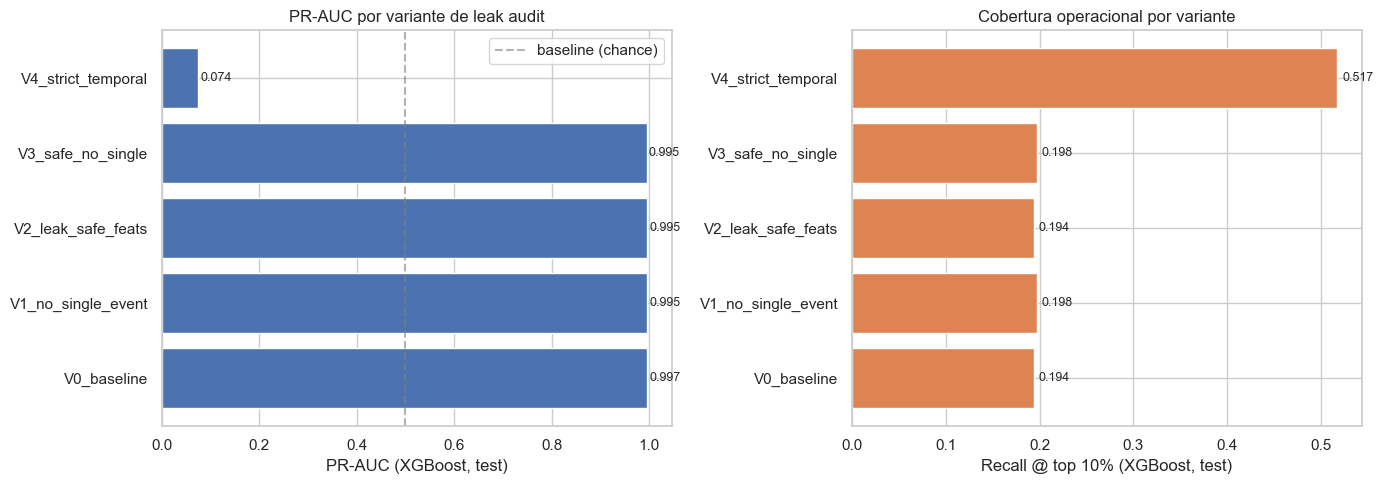

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

audit_plot = audit.reset_index()
axes[0].barh(audit_plot["variant"], audit_plot["pr_auc"], color="#4c72b0")
axes[0].set_xlabel("PR-AUC (XGBoost, test)")
axes[0].set_title("PR-AUC por variante de leak audit")
axes[0].axvline(0.5, color="gray", linestyle="--", alpha=0.6, label="baseline (chance)")
for i, v in enumerate(audit_plot["pr_auc"]):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
axes[0].legend()

axes[1].barh(audit_plot["variant"], audit_plot["recall_top10"], color="#dd8452")
axes[1].set_xlabel("Recall @ top 10% (XGBoost, test)")
axes[1].set_title("Cobertura operacional por variante")
for i, v in enumerate(audit_plot["recall_top10"]):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 5. Conclusão

Compare especialmente:
- **V0 → V1:** quanto a PR-AUC cai ao remover os ~29% de single-event VINs. Diferença grande = boa parte da performance vem desse subconjunto degenerado.
- **V0 → V2:** quanto cai ao remover apenas as features contaminadas (gap_*, age_at_last_service, is_warranty_active). Diferença grande = essas features carregavam mesmo o sinal do target.
- **V3:** combinação mínima sem leak por features e sem o subconjunto degenerado, com split aleatório.
- **V4:** mais rigorosa — só features que não tocam `last_service_date`, sem single-event, e com split temporal por coorte de compra. **Este é o limite inferior defensável da performance real do modelo.** O que aparece aqui é o que sobrevive a uma auditoria séria de leakage.

A V4 é o valor a citar no relatório acadêmico/MODEL_CARD como "performance estimada em produção". As outras variantes mostram o caminho até lá, evidenciando a contribuição de cada fonte de leak.